# Bai tap: ETHUSDs (Forex)/ ETHUSDT 1m tren Forex hoac Binace
### Mot chien luoc mua: Khi gia du doan > Gia thuc te va MA 10 > MA 20
### Mot chien luoc ban: Khi gia du doan < Gia thuc te va MA 10 < MA 20

# 1. Lay du lieu 1 ma

In [15]:
# Forex
import sys
sys.path.append('../Common')

import CommonSSIDWH

symbol = 'VCB'
from_date = '2024-01-01'
to_date = '2024-12-06'

data = CommonSSIDWH.CommonSSIDWH.loaddataSSI_Ext(symbol, from_date, to_date, '')

In [2]:
data

,Datetime,Open,High,Low,Close,Volume
0,2024-01-02,82900,83600,82200,83500,1785800
1,2024-01-03,83500,84500,82800,84500,1373000
2,2024-01-04,84500,86200,84000,85900,2657900
3,2024-01-05,85900,86200,85700,86200,1180300
4,2024-01-08,86300,86800,86300,86800,1607800
...,...,...,...,...,...,...
228,2024-12-02,94900,95100,93900,94200,1573100
229,2024-12-03,94400,94400,92600,93000,2445800
230,2024-12-04,92800,93900,92500,93500,1204400
231,2024-12-05,93000,94600,93000,94000,2333000


In [3]:
data.to_csv('data.csv')

In [16]:
import pandas as pd
data['Open'] = pd.to_numeric(data['Open'])
data['High'] = pd.to_numeric(data['High'])
data['Low'] = pd.to_numeric(data['Low'])
data['Close'] = pd.to_numeric(data['Close'])
data['Volume'] = pd.to_numeric(data['Volume'])

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Datetime  233 non-null    datetime64[ns]
 1   Open      233 non-null    int64         
 2   High      233 non-null    int64         
 3   Low       233 non-null    int64         
 4   Close     233 non-null    int64         
 5   Volume    233 non-null    int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 11.1 KB


# Xu ly chi bao va ML va tinh toan Buy_Signal; Sell_Signal

In [17]:
# Code
import talib
from sklearn.linear_model import LinearRegression 
import redis 
from datetime import datetime, timedelta
import time
import pandas as pd 
import numpy as np

# Them chi bao
data['MA10'] = talib.SMA(data['Close'], timeperiod=10)
data['MA20'] = talib.SMA(data['Close'], timeperiod=20)

# Xu ly NA: Drop NA
data = data.dropna()

# Khoi tao Feature va Target
X = data[['Open', 'High', 'Low', 'Volume', 'MA10', 'MA20']] # Feature
y = data['Close'] # Target

model = LinearRegression()
model.fit(X, y)

# Du doan
data['Predicted_Close'] = model.predict(X)

# Tinh toan Buy_Signal va Sell Signal
data['Buy_Signal'] = ((data['Predicted_Close'] > data['Close']) & (data['MA10'] > data['MA20']))
data['Sell_Signal'] = ((data['Predicted_Close'] < data['Close']) & (data['MA10'] < data['MA20']))

# Day sang Redis
# Tạo kết nối Redis
r = redis.Redis(host='localhost', port=6379, db=5) # DB muon chua # CK 0-5; FX 6-10; Crypto 11-15
# Tạo hash key
hash_key = 'OG_ML_CK_MA10, MA20'

last_record = data.iloc[-1] # Lay record moi nhat

# Chuyển đổi record cuối cùng thành từ điển và lưu vào Redis dưới dạng hash
if(last_record['Buy_Signal'] == True or last_record['Sell_Signal'] == True):
	for field, value in last_record.to_dict().items():
		# Chuyển đổi giá trị uint64 và Timestamp thành chuỗi
		if isinstance(value, pd.Timestamp):
			value = value.isoformat()
		elif isinstance(value, (int, np.uint64)):
			value = str(value)
		r.hset(hash_key, field, value)  
		r.hset(hash_key, 'Symbol', symbol)
		r.hset(hash_key, 'Insertdate', datetime.now().isoformat())
		last_record['Insertdate'] = datetime.now().isoformat()
	print(last_record)   
else:
	print(last_record)   
	print('Không có tín hiệu!')


Datetime                  2024-12-06 00:00:00
Open                                    94000
High                                    95300
Low                                     93900
Close                                   94200
Volume                                1700100
MA10                                  93120.0
MA20                                  92185.0
Predicted_Close                  94648.896948
Buy_Signal                               True
Sell_Signal                             False
Insertdate         2024-12-06T22:17:23.297472
Name: 232, dtype: object


C:\Users\PCDTT\AppData\Local\Temp\ipykernel_7736\1314844191.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_record['Insertdate'] = datetime.now().isoformat()
C:\Users\PCDTT\AppData\Local\Temp\ipykernel_7736\1314844191.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_record['Insertdate'] = datetime.now().isoformat()


# Backtest cho data

In [18]:
data

,Datetime,Open,High,Low,Close,Volume,MA10,MA20,Predicted_Close,Buy_Signal,Sell_Signal
19,2024-01-29,91800,92000,90900,91200,730500,91340.0,89280.0,91162.516222,False,False
20,2024-01-30,91200,91200,90100,91000,888600,91440.0,89655.0,90278.665197,False,False
21,2024-01-31,90600,90600,88500,88500,945600,91200.0,89855.0,89036.033122,True,False
22,2024-02-01,88000,90200,88000,89800,598100,91070.0,90050.0,89562.066876,False,False
23,2024-02-02,89100,90500,89100,90300,733000,90840.0,90255.0,89987.965783,False,False
...,...,...,...,...,...,...,...,...,...,...,...
228,2024-12-02,94900,95100,93900,94200,1573100,91790.0,91995.0,94041.843022,False,True
229,2024-12-03,94400,94400,92600,93000,2445800,92090.0,92015.0,92869.261467,False,False
230,2024-12-04,92800,93900,92500,93500,1204400,92410.0,92045.0,93179.653058,False,False
231,2024-12-05,93000,94600,93000,94000,2333000,92760.0,92085.0,93936.856104,False,False


Ngày vào lệnh đầu tiên: 22
Tổng lợi nhuận: 5600000
Tổng giá trị tài khoản: 105600000
Lợi nhuận thị trường: 3.289473684210526%
Lợi nhuận chiến lược: 5.6000000000000005%


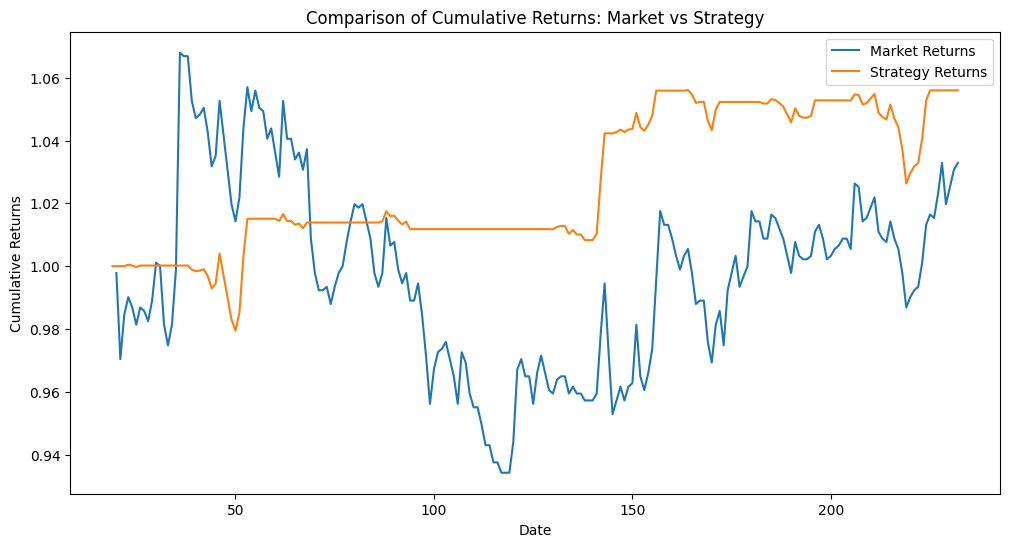

In [19]:
import CommonBacktest

dataBacktest = CommonBacktest.CommonBacktest.backtest(data, 100000000, 100)

In [20]:
dataBacktest.to_csv('data_out_backtest.csv')

# 2. Lay du lieu la 1 danh sach Symbol

In [2]:
# Forex
import sys
sys.path.append('../Common')

import CommonSSIDWH

symbols = ['VCB', 'STB', 'ACB']
from_date = '2024-10-15'
to_date = '2024-12-06'

dataList = CommonSSIDWH.CommonSSIDWH.loaddataSSI_Ext_ListSymbol(symbols, from_date, to_date, '')

Đang xử lý mã: VCB
Lấy dữ liệu VCB từ 15/10/2024 đến 06/12/2024 thành công!
Đang xử lý mã: STB
Lấy dữ liệu STB từ 15/10/2024 đến 06/12/2024 thành công!
Đang xử lý mã: ACB
Lấy dữ liệu ACB từ 15/10/2024 đến 06/12/2024 thành công!


In [4]:
dataList

,Datetime,Symbol,Open,High,Low,Close,Volume
0,2024-10-15,VCB,91300,92100,91300,91400,1430600
1,2024-10-16,VCB,91400,91800,91300,91500,1293000
2,2024-10-17,VCB,92000,92300,91700,92200,1285400
3,2024-10-18,VCB,92700,93100,92000,92400,1162700
4,2024-10-21,VCB,92500,93300,92000,92000,1423100
...,...,...,...,...,...,...,...
112,2024-12-02,ACB,25250,25350,25050,25150,2487700
113,2024-12-03,ACB,25200,25200,24950,25000,6127300
114,2024-12-04,ACB,24950,25050,24850,25050,4616000
115,2024-12-05,ACB,25000,25700,24950,25700,8267100


In [12]:
dataList['Symbol'].unique()
import pandas as pd
dataList['Open'] = pd.to_numeric(dataList['Open'])
dataList['High'] = pd.to_numeric(dataList['High'])
dataList['Low'] = pd.to_numeric(dataList['Low'])
dataList['Close'] = pd.to_numeric(dataList['Close'])
dataList['Volume'] = pd.to_numeric(dataList['Volume'])
dataList.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Datetime  117 non-null    datetime64[ns]
 1   Symbol    117 non-null    object        
 2   Open      117 non-null    int64         
 3   High      117 non-null    int64         
 4   Low       117 non-null    int64         
 5   Close     117 non-null    int64         
 6   Volume    117 non-null    int64         
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 6.5+ KB


In [13]:
import talib
from sklearn.linear_model import LinearRegression 
import redis 
from datetime import datetime, timedelta
import time
import pandas as pd 
import numpy as np

# Xu ly theo tung ma day sang Redis
# Lặp qua từng mã trong danh sách Symbol
for symbol in dataList['Symbol'].unique():
	print(f"Đang xử lý dữ liệu cho mã: {symbol}")
	
	# Lọc dữ liệu cho mã hiện tại
	symbol_data = dataList[dataList['Symbol'] == symbol].sort_values(by='Datetime').copy()  # Sao chép để tránh cảnh báo SettingWithCopy

	symbol_data['MA10'] = talib.SMA(symbol_data['Close'], timeperiod=10)
	symbol_data['MA20'] = talib.SMA(symbol_data['Close'], timeperiod=20)

	# Xu ly NA: Drop NA
	symbol_data = symbol_data.dropna()

	# Khoi tao Feature va Target
	X = symbol_data[['Open', 'High', 'Low', 'Volume', 'MA10', 'MA20']] # Feature
	y = symbol_data['Close'] # Target

	model = LinearRegression()
	model.fit(X, y)

	# Du doan
	symbol_data['Predicted_Close'] = model.predict(X)

	# Tinh toan Buy_Signal va Sell Signal
	symbol_data['Buy_Signal'] = ((symbol_data['Predicted_Close'] > symbol_data['Close']) & (symbol_data['MA10'] > symbol_data['MA20']))
	symbol_data['Sell_Signal'] = ((symbol_data['Predicted_Close'] < symbol_data['Close']) & (symbol_data['MA10'] < symbol_data['MA20']))

	# Day sang Redis
	# Tạo kết nối Redis
	r = redis.Redis(host='localhost', port=6379, db=5) # DB muon chua # CK 0-5; FX 6-10; Crypto 11-15
	# Tạo hash key
	hash_key = 'OG_ML_CK_MA10, MA20_' + symbol

	last_record = symbol_data.iloc[-1] # Lay record moi nhat

	# Chuyển đổi record cuối cùng thành từ điển và lưu vào Redis dưới dạng hash
	if(last_record['Buy_Signal'] == True or last_record['Sell_Signal'] == True):
		for field, value in last_record.to_dict().items():
			# Chuyển đổi giá trị uint64 và Timestamp thành chuỗi
			if isinstance(value, pd.Timestamp):
				value = value.isoformat()
			elif isinstance(value, (int, np.uint64)):
				value = str(value)
			r.hset(hash_key, field, value)  
			r.hset(hash_key, 'Symbol', symbol)
			r.hset(hash_key, 'Insertdate', datetime.now().isoformat())
			last_record['Insertdate'] = datetime.now().isoformat()
		print(last_record)   
	else:
		print(last_record)   
		print('Không có tín hiệu!')
	

Đang xử lý dữ liệu cho mã: VCB


C:\Users\PCDTT\AppData\Local\Temp\ipykernel_7736\2013085862.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_record['Insertdate'] = datetime.now().isoformat()
C:\Users\PCDTT\AppData\Local\Temp\ipykernel_7736\2013085862.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_record['Insertdate'] = datetime.now().isoformat()


Datetime                  2024-12-06 00:00:00
Symbol                                    VCB
Open                                    94000
High                                    95300
Low                                     93900
Close                                   94200
Volume                                1700100
MA10                                  93120.0
MA20                                  92185.0
Predicted_Close                  94632.696585
Buy_Signal                               True
Sell_Signal                             False
Insertdate         2024-12-06T22:15:31.814637
Name: 38, dtype: object
Đang xử lý dữ liệu cho mã: STB


C:\Users\PCDTT\AppData\Local\Temp\ipykernel_7736\2013085862.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_record['Insertdate'] = datetime.now().isoformat()
C:\Users\PCDTT\AppData\Local\Temp\ipykernel_7736\2013085862.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_record['Insertdate'] = datetime.now().isoformat()


Datetime                  2024-12-06 00:00:00
Symbol                                    STB
Open                                    33900
High                                    33950
Low                                     33600
Close                                   33800
Volume                                5016000
MA10                                  33155.0
MA20                                  32992.5
Predicted_Close                  33816.572381
Buy_Signal                               True
Sell_Signal                             False
Insertdate         2024-12-06T22:15:33.887564
Name: 77, dtype: object
Đang xử lý dữ liệu cho mã: ACB
Datetime                  2024-12-06 00:00:00
Symbol                                    ACB
Open                                    25500
High                                    25750
Low                                     25500
Close                                   25650
Volume                                6049500
MA10                     

C:\Users\PCDTT\AppData\Local\Temp\ipykernel_7736\2013085862.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_record['Insertdate'] = datetime.now().isoformat()
C:\Users\PCDTT\AppData\Local\Temp\ipykernel_7736\2013085862.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_record['Insertdate'] = datetime.now().isoformat()
